In [110]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformacion import (
    calcular_retornos_simples,
    calcular_retornos_log
)

# 🔄 1.1 Retornos simples y logarítmicos

In [111]:
# precios de cierre del portafolio
tickers = ["AAPL", "AMZN", "JPM", "GS", "TSLA"]
inicio = "2021-01-01"
fin = "2024-12-31"

In [112]:
precios = yf.download(
    tickers,
    start=inicio,
    end=fin,
    auto_adjust=True
)["Close"]

print("Precios de cierre:")
print(precios.head())

[*********************100%***********************]  5 of 5 completed

Precios de cierre:
Ticker            AAPL        AMZN          GS         JPM        TSLA
2021-01-04  125.740852  159.331497  233.060944  109.491570  243.256668
2021-01-05  127.295509  160.925507  238.276276  110.087349  245.036667
2021-01-06  123.010521  156.919006  251.134186  115.256599  251.993332
2021-01-07  127.208038  158.108002  256.498932  119.041534  272.013336
2021-01-08  128.306000  159.134995  255.118301  119.172928  293.339996


In [113]:
# retornos diarios simples y logarítmicos
retornos_simples = calcular_retornos_simples(precios)
retornos_log = calcular_retornos_log(precios)

print("Retornos simples")
display(retornos_simples.head())

print("Retornos logarítmicos")
display(retornos_log.head())

Retornos simples


Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-05,0.012364,0.010004,0.022378,0.005441,0.007317
2021-01-06,-0.033662,-0.024897,0.053962,0.046956,0.028390
2021-01-07,0.034123,0.007577,0.021362,0.032839,0.079447
2021-01-08,0.008631,0.006496,-0.005383,0.001104,0.078403
2021-01-11,-0.023249,-0.021519,0.012927,0.014924,-0.078214


Retornos logarítmicos


Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-05,0.012288,0.009955,0.022131,0.005427,0.007291
2021-01-06,-0.034241,-0.025212,0.052557,0.045887,0.027995
2021-01-07,0.033554,0.007549,0.021137,0.032312,0.076448
2021-01-08,0.008594,0.006475,-0.005397,0.001103,0.075481
2021-01-11,-0.023523,-0.021754,0.012844,0.014814,-0.081442


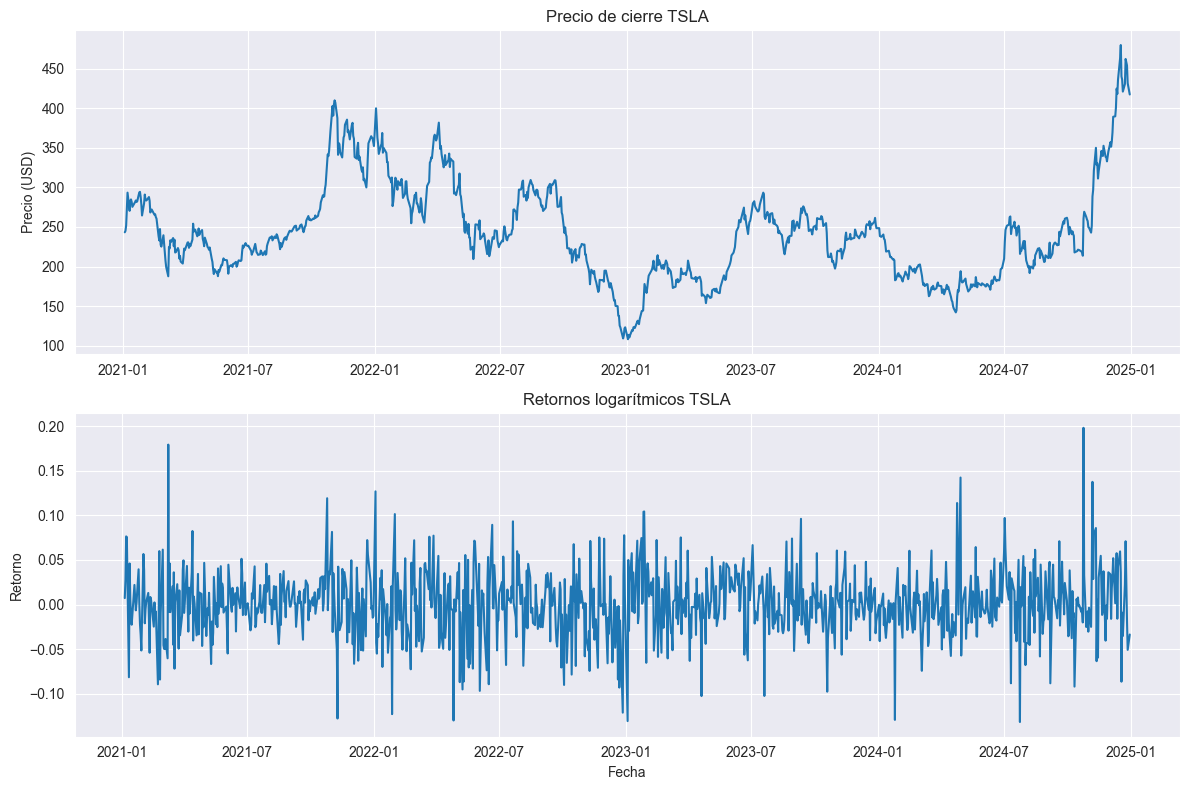

In [114]:
# TSLA
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(precios.index, precios["TSLA"])
axes[0].set_title("Precio de cierre TSLA")
axes[0].set_ylabel("Precio (USD)")
axes[0].grid(True)

axes[1].plot(retornos_log.index, retornos_log["TSLA"])
axes[1].set_title("Retornos logarítmicos TSLA")
axes[1].set_ylabel("Retorno")
axes[1].set_xlabel("Fecha")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Diferencia entre retornos
La principal diferencia es que los retornos simples muestran directamente la variación porcentual entre dos periodos, mientras que los logaritmicos utilizan el logaritmo de la razón entre precios.
Los retornos logaritmicos son más convenientes para analisis financieros porque permiten sumar retornos a través del tiempo y facilitan el uso de modelos estadisticos. Por otra parte, los retornos simples son mas faciles de interpretar para medir ganancias o pérdidas porcentuales.

# 🔄 1.2 Retornos multi-período y estadísticos descriptivos

In [115]:
# JPM
jpm = precios["JPM"]
# Retornos diarios
ret_diario_simple = jpm.pct_change().dropna()
ret_diario_log = np.log(jpm / jpm.shift(1)).dropna()

# Retornos semanales
jpm_semanal = jpm.resample("W").last()

ret_semanal_simple = jpm_semanal.pct_change().dropna()
ret_semanal_log = np.log(jpm_semanal / jpm_semanal.shift(1)).dropna()

# Retornos mensuales
jpm_mensual = jpm.resample("ME").last()

ret_mensual_simple = jpm_mensual.pct_change().dropna()
ret_mensual_log = np.log(jpm_mensual / jpm_mensual.shift(1)).dropna()

print("Retornos diarios")
display(ret_diario_log.head())

print("Retornos semanales")
display(ret_semanal_log.head())

print("Retornos mensuales")
display(ret_mensual_log.head())

Retornos diarios


2021-01-05    0.005427
2021-01-06    0.045887
2021-01-07    0.032312
2021-01-08    0.001103
2021-01-11    0.014814
Name: JPM, dtype: float64

Retornos semanales


2021-01-17    0.019079
2021-01-24   -0.035609
2021-01-31   -0.039020
2021-02-07    0.069858
2021-02-14    0.023423
Freq: W-SUN, Name: JPM, dtype: float64

Retornos mensuales


2021-02-28    0.134337
2021-03-31    0.033804
2021-04-30    0.016198
2021-05-31    0.065611
2021-06-30   -0.054426
Freq: ME, Name: JPM, dtype: float64

In [116]:
# Retorno acumulado rolling de 20 días
ret_roll_20 = ret_diario_log.rolling(window=20).sum()

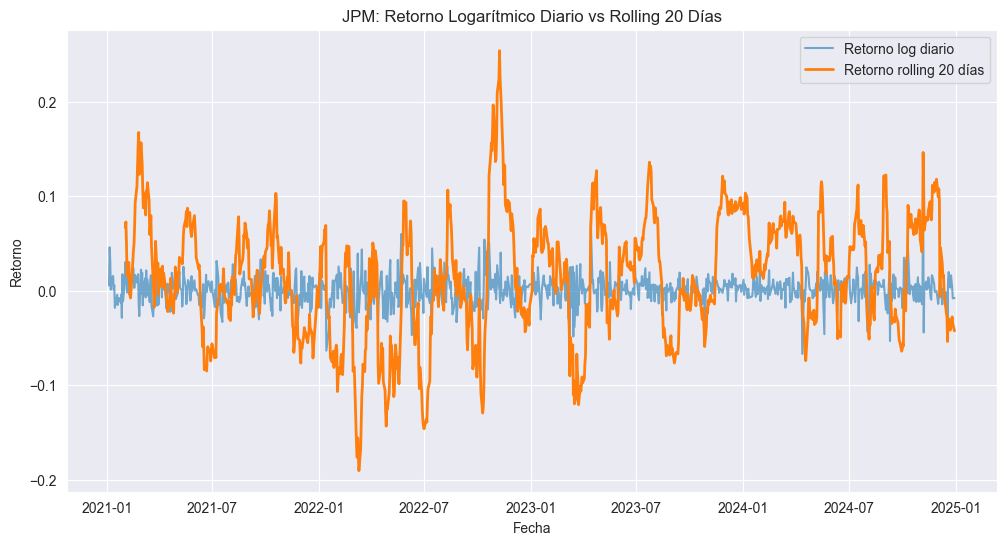

In [117]:
plt.figure(figsize=(12,6))

plt.plot(
    ret_diario_log.index,
    ret_diario_log,
    label="Retorno log diario",
    alpha=0.6
)

plt.plot(
    ret_roll_20.index,
    ret_roll_20,
    label="Retorno rolling 20 días",
    linewidth=2
)

plt.title("JPM: Retorno Logarítmico Diario vs Rolling 20 Días")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.legend()
plt.grid(True)

plt.show()

In [118]:
resumen = pd.DataFrame({
    "Media": [
        ret_diario_log.mean(),
        ret_semanal_log.mean(),
        ret_mensual_log.mean()
    ],
    "Desv_Est": [
        ret_diario_log.std(),
        ret_semanal_log.std(),
        ret_mensual_log.std()
    ],
    "Skewness": [
        ret_diario_log.skew(),
        ret_semanal_log.skew(),
        ret_mensual_log.skew()
    ],
    "Curtosis": [
        ret_diario_log.kurt(),
        ret_semanal_log.kurt(),
        ret_mensual_log.kurt()
    ]
},
index=["Diario", "Semanal", "Mensual"])

resumen

,Media,Desv_Est,Skewness,Curtosis
Diario,0.000749,0.015174,0.186646,4.402298
Semanal,0.003205,0.033794,-0.227738,0.662752
Mensual,0.015366,0.072663,-0.098797,-0.071205


# 1.3 Estandarización y Normalización

In [119]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Retornos simples diarios del portafolio
retornos = retornos_simples.copy()

# Estandarización
scaler_std = StandardScaler()
retornos_std = pd.DataFrame(
    scaler_std.fit_transform(retornos),
    columns=retornos.columns,
    index=retornos.index
)

# Normalización Min-Max
scaler_mm = MinMaxScaler()
retornos_mm = pd.DataFrame(
    scaler_mm.fit_transform(retornos),
    columns=retornos.columns,
    index=retornos.index
)

print("Retornos estandarizados")
display(retornos_std.head())

print("Retornos normalizados")
display(retornos_mm.head())

Retornos estandarizados


Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-05,0.688616,0.424192,1.292703,0.300976,0.160444
2021-01-06,-2.058764,-1.145841,3.203034,3.031101,0.717604
2021-01-07,1.987477,0.315002,1.231285,2.102744,2.067511
2021-01-08,0.465800,0.266345,-0.386310,0.015725,2.039919
2021-01-11,-1.437190,-0.993919,0.721103,0.924618,-2.100974


Retornos normalizados


Ticker,AAPL,AMZN,GS,JPM,TSLA
2021-01-05,0.481148,0.545575,0.458751,0.389285,0.381458
2021-01-06,0.169435,0.419055,0.616165,0.619764,0.442979
2021-01-07,0.628515,0.536776,0.453690,0.541391,0.592032
2021-01-08,0.455868,0.532855,0.320398,0.365204,0.588986
2021-01-11,0.239958,0.431298,0.411650,0.441933,0.131758


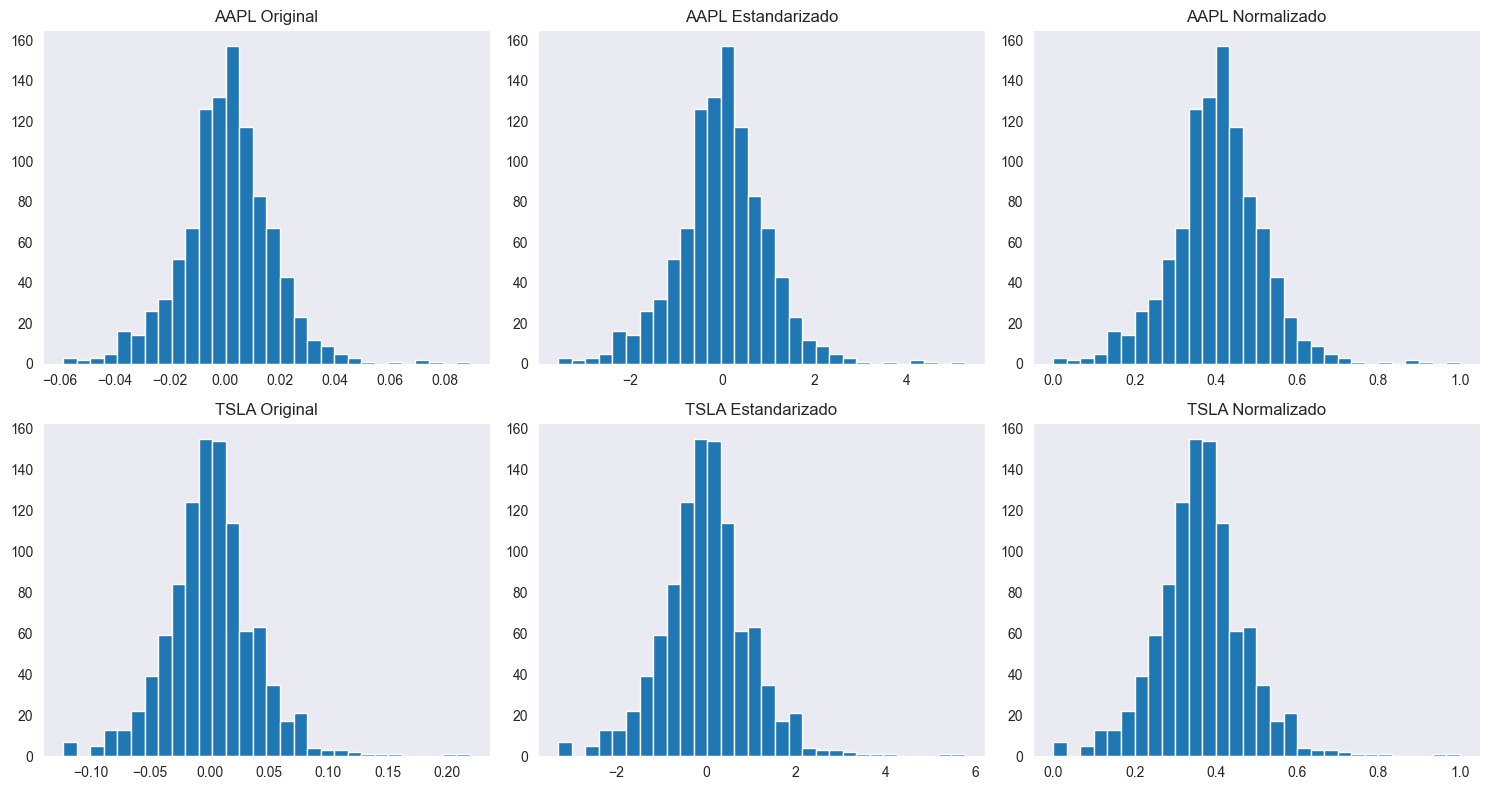

In [120]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# AAPL
ax[0,0].hist(retornos["AAPL"], bins=30)
ax[0,0].set_title("AAPL Original")

ax[0,1].hist(retornos_std["AAPL"], bins=30)
ax[0,1].set_title("AAPL Estandarizado")

ax[0,2].hist(retornos_mm["AAPL"], bins=30)
ax[0,2].set_title("AAPL Normalizado")

# TSLA
ax[1,0].hist(retornos["TSLA"], bins=30)
ax[1,0].set_title("TSLA Original")

ax[1,1].hist(retornos_std["TSLA"], bins=30)
ax[1,1].set_title("TSLA Estandarizado")

ax[1,2].hist(retornos_mm["TSLA"], bins=30)
ax[1,2].set_title("TSLA Normalizado")

plt.tight_layout()
plt.show()

# Transformación 
La estandarización es la transformación más adecuada para comparar la volatilidad entre los activos, ya que considera la media y la desviación estándar de cada serie. Esto permite comparar los retornos en una misma escala sin perder información sobre su dispersión.
En cambio, la normalización solo ajusta los datos a un rango entre 0 y 1, por lo que es útil para comparar valores, pero no para analizar diferencias de volatilidad o riesgo entre los activos.

# ↔️ 2.1 Matrices de Correlación

In [121]:
# Matrices de correlación

corr_pearson = retornos_simples.corr(method="pearson")
corr_spearman = retornos_simples.corr(method="spearman")
corr_kendall = retornos_simples.corr(method="kendall")

print("Pearson")
display(corr_pearson)

print("Spearman")
display(corr_spearman)

print("Kendall")
display(corr_kendall)

Pearson


Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,1.000000,0.562225,0.332048,0.294701,0.492028
AMZN,0.562225,1.000000,0.359424,0.295769,0.427575
GS,0.332048,0.359424,1.000000,0.763537,0.287263
JPM,0.294701,0.295769,0.763537,1.000000,0.261379
TSLA,0.492028,0.427575,0.287263,0.261379,1.000000


Spearman


Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,1.000000,0.595989,0.332785,0.292708,0.503431
AMZN,0.595989,1.000000,0.331140,0.272548,0.458631
GS,0.332785,0.331140,1.000000,0.745486,0.302996
JPM,0.292708,0.272548,0.745486,1.000000,0.275196
TSLA,0.503431,0.458631,0.302996,0.275196,1.000000


Kendall


Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,1.000000,0.431532,0.230996,0.204107,0.352098
AMZN,0.431532,1.000000,0.228477,0.189082,0.320922
GS,0.230996,0.228477,1.000000,0.562399,0.207611
JPM,0.204107,0.189082,0.562399,1.000000,0.187273
TSLA,0.352098,0.320922,0.207611,0.187273,1.000000


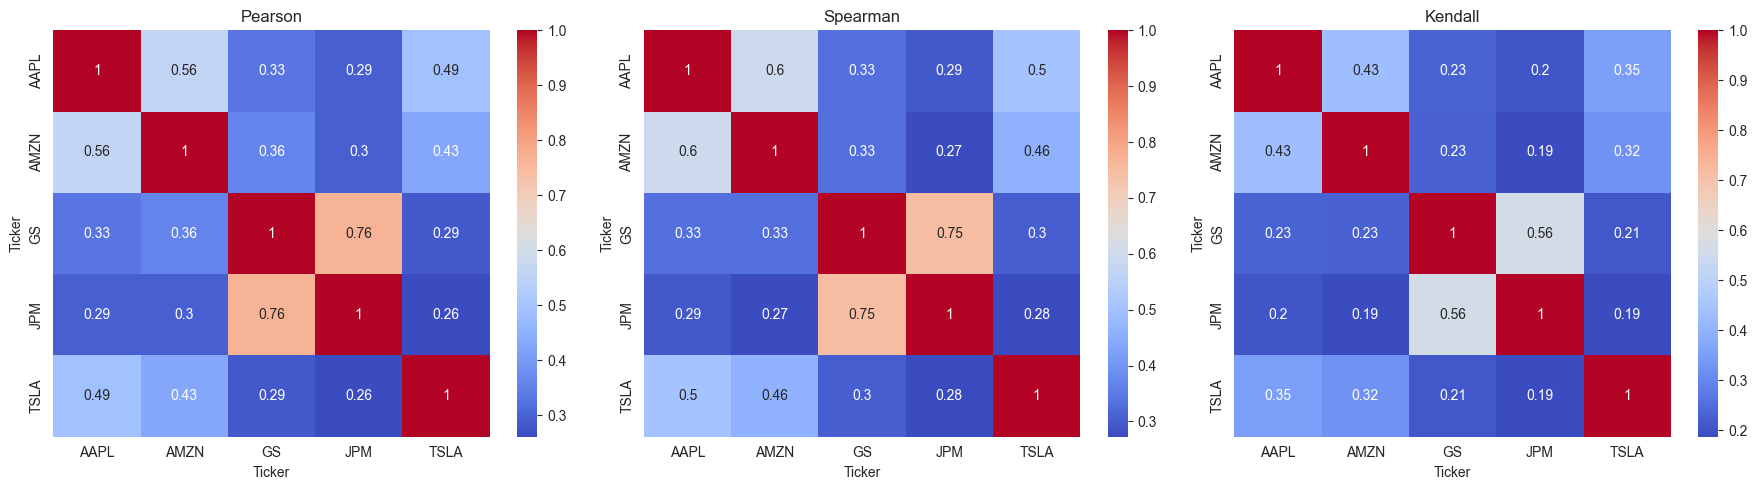

In [122]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    corr_pearson,
    annot=True,
    cmap="coolwarm",
    ax=ax[0]
)
ax[0].set_title("Pearson")

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap="coolwarm",
    ax=ax[1]
)
ax[1].set_title("Spearman")

sns.heatmap(
    corr_kendall,
    annot=True,
    cmap="coolwarm",
    ax=ax[2]
)
ax[2].set_title("Kendall")

plt.tight_layout()
plt.show()

In [123]:
# Eliminar diagonal
corr_aux = corr_pearson.where(
    np.triu(np.ones(corr_pearson.shape), k=1).astype(bool)
)

max_corr = corr_aux.stack().idxmax()
min_corr = corr_aux.stack().idxmin()

print("Mayor correlación Pearson:")
print(max_corr, "=", corr_aux.stack().max())

print("\nMenor correlación Pearson:")
print(min_corr, "=", corr_aux.stack().min())

Mayor correlación Pearson:
('GS', 'JPM') = 0.7635365491508229

Menor correlación Pearson:
('JPM', 'TSLA') = 0.2613794683144252


El par con mayor correlación de Pearson fue GS-JPM con una correlación de 0.76, mientras que el par con menor correlación fue JPM-TSLA con una correlación de 0.26.

# Comparación
Las correlaciones de Pearson y Spearman son muy parecidas, por lo que ambos métodos muestran conclusiones similares. En los dos casos, GS y JPM presentan la relación más fuerte, mientras que JPM y TSLA muestran una de las más bajas.
Las pequeñas diferencias se deben a que Pearson mide relaciones lineales y Spearman se basa en el orden de los datos. Como los retornos financieros pueden tener movimientos extremos, Spearman suele verse menos afectado por estos casos. Sin embargo, en este análisis las diferencias fueron mínimas.

# ↔️ 2.2 Matriz de Covarianza

In [124]:
# Retornos mensuales simples del portafolio
precios_mensuales = precios.resample("ME").last()

retornos_mensuales = precios_mensuales.pct_change().dropna()

# Matriz de covarianzas
sigma = retornos_mensuales.cov()

print("Matriz de Covarianzas")
display(sigma)

Matriz de Covarianzas


Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,0.005452,0.004582,0.002046,0.001129,0.007980
AMZN,0.004582,0.008780,0.002156,0.001260,0.010944
GS,0.002046,0.002156,0.006626,0.005119,0.003233
JPM,0.001129,0.001260,0.005119,0.005446,0.001130
TSLA,0.007980,0.010944,0.003233,0.001130,0.032387


In [125]:
# Valores propios
eigenvalues = np.linalg.eigvals(sigma)

print("Valores propios:")
print(eigenvalues)

Valores propios:
[0.03984996 0.0109712  0.00484331 0.00221905 0.00080758]


Para que la matriz de covarianzas sea semidefinida positiva, sus valores propios deben ser mayores o iguales a cero. Valores muy pequeños o cercanos a cero suelen deberse a errores de redondeo numérico.

In [126]:
vol_anual = retornos_mensuales.std() * np.sqrt(12)

vol_df = pd.DataFrame({
    "Volatilidad Anualizada": vol_anual
})

vol_df

,Volatilidad Anualizada
Ticker,
AAPL,0.255780
AMZN,0.324587
GS,0.281983
JPM,0.255649
TSLA,0.623412


In [127]:
cov_aux = sigma.where(
    np.triu(np.ones(sigma.shape), k=1).astype(bool)
)

mejor_div = cov_aux.stack().idxmin()

print("Par con menor covarianza:")
print(mejor_div)

print("Covarianza:")
print(cov_aux.stack().min())

Par con menor covarianza:
('AAPL', 'JPM')
Covarianza:
0.001128840024324697


# Par con mejor diversificación 
El par de activos con menor covarianza ofrece una mejor diversificación, ya que sus retornos no se mueven de forma tan similar. Esto ayuda a reducir el riesgo del portafolio al combinar activos con comportamientos distintos.

# 🔄 2.3 Correlaciones Rodantes (Rolling Correlation)

In [128]:
# Correlación rolling de 60 días entre AAPL y JPM

rolling_corr = (
    retornos_simples["AAPL"]
    .rolling(window=60)
    .corr(retornos_simples["JPM"])
)

rolling_corr.head()

2021-01-05   NaN
2021-01-06   NaN
2021-01-07   NaN
2021-01-08   NaN
2021-01-11   NaN
dtype: float64

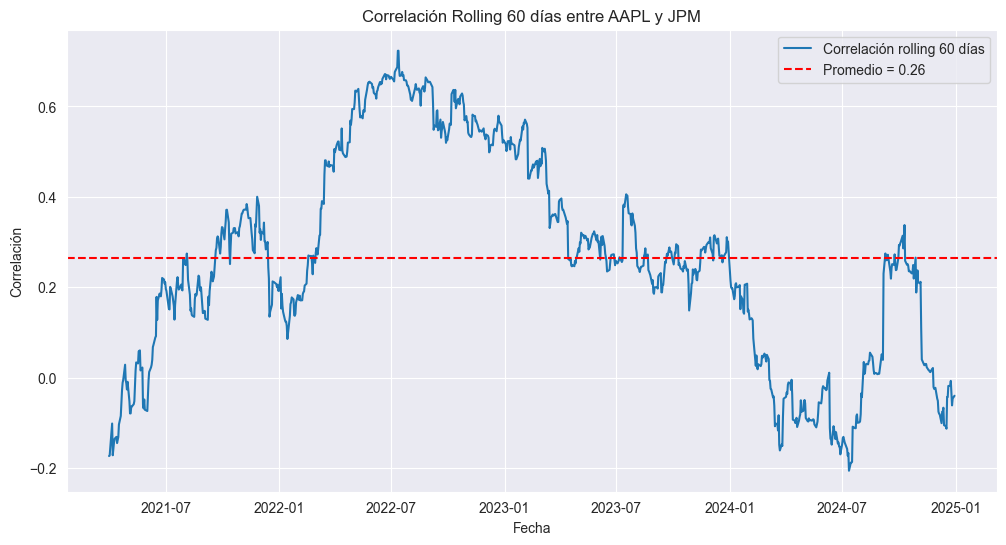

In [129]:
# Correlación promedio
corr_promedio = rolling_corr.mean()

plt.figure(figsize=(12,6))

plt.plot(
    rolling_corr.index,
    rolling_corr,
    label="Correlación rolling 60 días"
)

plt.axhline(
    corr_promedio,
    color="red",
    linestyle="--",
    label=f"Promedio = {corr_promedio:.2f}"
)

plt.title("Correlación Rolling 60 días entre AAPL y JPM")
plt.xlabel("Fecha")
plt.ylabel("Correlación")
plt.legend()
plt.grid(True)

plt.show()

# Correlación
Se observa una correlación alta entre mediados de 2022 y comienzos de 2023, alcanzando valores cercanos a 0,7. Esto puede explicarse por la incertidumbre económica y las alzas de tasas de interés, que afectaron a gran parte del mercado de forma similar, debido al efecto pandemia y la guerra Rusia-Ucrania 
En cambio, durante 2024 la correlación fue mucho más baja e incluso negativa en algunos períodos. Esto indica que AAPL y JPM reaccionaron de manera diferente a las condiciones del mercado, ya que pertenecen a sectores distintos, tecnológico y financiero.
En general, la correlación entre ambos activos no fue constante y cambió según el contexto económico de cada período.

# 👁 3.1 Visualización de Distribuciones

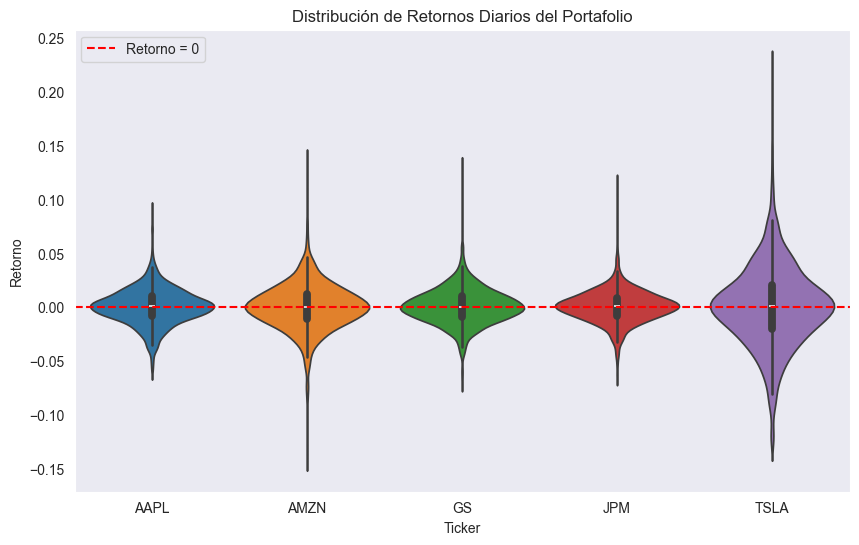

In [130]:
# Violin plot de los retornos diarios

plt.figure(figsize=(10,6))

sns.violinplot(data=retornos_simples)

# Línea horizontal en 0
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    label="Retorno = 0"
)

plt.title("Distribución de Retornos Diarios del Portafolio")
plt.ylabel("Retorno")
plt.legend()

plt.show()

# Dispersión y distribución
TSLA es el activo que muestra la mayor dispersión de retornos, ya que su distribución es más ancha y alcanza valores más extremos que los demás activos. Esto significa que sus retornos varían más y, por lo tanto, presenta un mayor nivel de riesgo.
Además, TSLA también tiene una distribución más asimétrica, porque sus movimientos positivos y negativos no están distribuidos de manera tan equilibrada como en otros activos.
TSLA es el activo más riesgoso del grupo, ya que puede generar ganancias más altas, pero también experimentar pérdidas más importantes. Por otro lado, activos como AAPL y JPM muestran un comportamiento más estable y menos volátil.

# 🟰 3.2 Tests de Igualdad de Medias 

In [131]:
from scipy.stats import f_oneway, kruskal, mannwhitneyu

# Series de retornos
aapl = retornos_simples["AAPL"]
amzn = retornos_simples["AMZN"]
jpm = retornos_simples["JPM"]
gs = retornos_simples["GS"]
tsla = retornos_simples["TSLA"]

# ANOVA
anova_stat, anova_p = f_oneway(
    aapl, amzn, jpm, gs, tsla
)

# Kruskal-Wallis
kruskal_stat, kruskal_p = kruskal(
    aapl, amzn, jpm, gs, tsla
)

# Mann-Whitney U (AAPL vs TSLA)
mw_stat, mw_p = mannwhitneyu(
    aapl,
    tsla,
    alternative="two-sided"
)

print("ANOVA:", anova_stat, anova_p)
print("Kruskal:", kruskal_stat, kruskal_p)
print("Mann-Whitney:", mw_stat, mw_p)

ANOVA: 0.11317915393087509 0.97793144708382
Kruskal: 0.2053669524480296 0.995075422302404
Mann-Whitney: 503017.5 0.9992311068131428


H₀: Las distribuciones (o medianas) de los retornos de AAPL y TSLA son iguales.

H₁: Las distribuciones (o medianas) de los retornos de AAPL y TSLA son diferentes.

In [132]:
alpha = 0.05

resultados = pd.DataFrame({
    "Test": ["ANOVA", "Kruskal-Wallis", "Mann-Whitney U"],
    "Estadístico": [anova_stat, kruskal_stat, mw_stat],
    "p-valor": [anova_p, kruskal_p, mw_p],
    "Decisión": [
        "Rechazar H0" if anova_p < alpha else "No rechazar H0",
        "Rechazar H0" if kruskal_p < alpha else "No rechazar H0",
        "Rechazar H0" if mw_p < alpha else "No rechazar H0"
    ]
})

resultados

,Test,Estadístico,p-valor,Decisión
0,ANOVA,0.113179,0.977931,No rechazar H0
1,Kruskal-Wallis,0.205367,0.995075,No rechazar H0
2,Mann-Whitney U,503017.500000,0.999231,No rechazar H0


# Tests paramétricos y no paramétricos
Los tres tests entregaron la misma conclusión, ya que en todos los casos el p-valor fue mayor a 0,05. Esto significa que no hay evidencia suficiente para decir que los retornos promedio de los activos son diferentes entre sí.
Los tests no paramétricos son útiles en finanzas porque los retornos de los activos no siempre se comportan de forma perfecta y pueden existir valores muy altos o muy bajos que afecten los resultados. Por eso, estos tests suelen ser una buena alternativa cuando los datos son más irregulares.

# 🟰 3.3 Tests de Igualdad de Varianzas

In [134]:
from scipy.stats import levene, bartlett

# Test de Levene
levene_stat, levene_p = levene(
    retornos_simples["AAPL"],
    retornos_simples["AMZN"],
    retornos_simples["JPM"],
    retornos_simples["GS"],
    retornos_simples["TSLA"]
)

# Test de Bartlett
bartlett_stat, bartlett_p = bartlett(
    retornos_simples["AAPL"],
    retornos_simples["AMZN"],
    retornos_simples["JPM"],
    retornos_simples["GS"],
    retornos_simples["TSLA"]
)

print("Levene:", levene_stat, levene_p)
print("Bartlett:", bartlett_stat, bartlett_p)

Levene: 185.43559464189676 2.0255624574436472e-148
Bartlett: 1318.3262228592137 3.5379304010814656e-284


In [135]:
alpha = 0.05

resultados_var = pd.DataFrame({
    "Test": ["Levene", "Bartlett"],
    "Estadístico": [levene_stat, bartlett_stat],
    "p-valor": [levene_p, bartlett_p],
    "Decisión": [
        "Rechazar H0" if levene_p < alpha else "No rechazar H0",
        "Rechazar H0" if bartlett_p < alpha else "No rechazar H0"
    ]
})

resultados_var

,Test,Estadístico,p-valor,Decisión
0,Levene,185.435595,2.025562e-148,Rechazar H0
1,Bartlett,1318.326223,3.537930e-284,Rechazar H0


# Volatilidad 
Tanto el test de Levene como el de Bartlett rechazan la hipótesis nula, ya que sus p-valores son mucho menores a 0,05. Esto indica que existen diferencias significativas en la volatilidad de los activos analizados, por lo que no todos presentan el mismo nivel de riesgo.
Para construir un portafolio diversificado, es importante considerar estas diferencias de volatilidad. Combinar activos con distintos niveles de riesgo puede ayudar a reducir la volatilidad total del portafolio y mejorar el equilibrio entre riesgo y retorno.

# Levene y Bartlett
Los resultados de Levene y Bartlett pueden ser diferentes porque Bartlett es más sensible a la forma en que se distribuyen los datos. En cambio, Levene funciona mejor cuando existen valores extremos o datos que no siguen una distribución normal.
Como los retornos financieros suelen presentar alta volatilidad y movimientos extremos, el test de Levene es adecuado para este tipo de análisis.

# 🔗 4.1 Distribución Muestral del Retorno Promedio

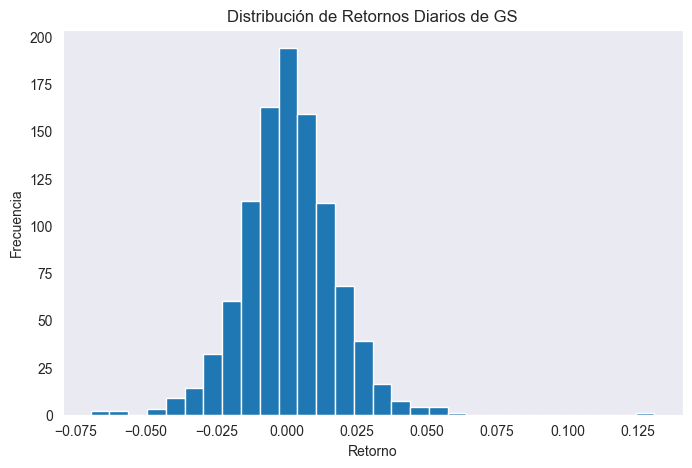

Asimetría: 0.4214433748634634
Curtosis: 4.568783356830691


In [136]:
# Retornos diarios de GS
gs = retornos_simples["GS"]

# Histograma
plt.figure(figsize=(8,5))
plt.hist(gs, bins=30)
plt.title("Distribución de Retornos Diarios de GS")
plt.xlabel("Retorno")
plt.ylabel("Frecuencia")
plt.show()

# Asimetría y curtosis
asimetria = gs.skew()
curtosis = gs.kurt()

print("Asimetría:", asimetria)
print("Curtosis:", curtosis)

La distribución de los retornos diarios de GS parece aproximarse a una distribución normal, ya que presenta una forma de campana y la mayoría de los valores se concentra cerca de cero. Sin embargo, también se observan algunos valores extremos en ambos lados de la distribución, por lo que no es perfectamente normal.
Los valores de asimetría y curtosis permiten complementar este análisis. Si la asimetría es cercana a cero, la distribución es relativamente simétrica. Por otro lado, una curtosis distinta de cero indica que la distribución presenta colas más o menos pronunciadas que una distribución normal.

In [137]:
# Tamaños muestrales
muestras = [5, 30, 60, 120, 252]

# Número de simulaciones
n_sim = 5000

resultados_mc = {}

for n in muestras:
    
    medias = []
    
    for _ in range(n_sim):
        muestra = np.random.choice(gs, size=n, replace=True)
        medias.append(np.mean(muestra))
        
    resultados_mc[n] = np.array(medias)

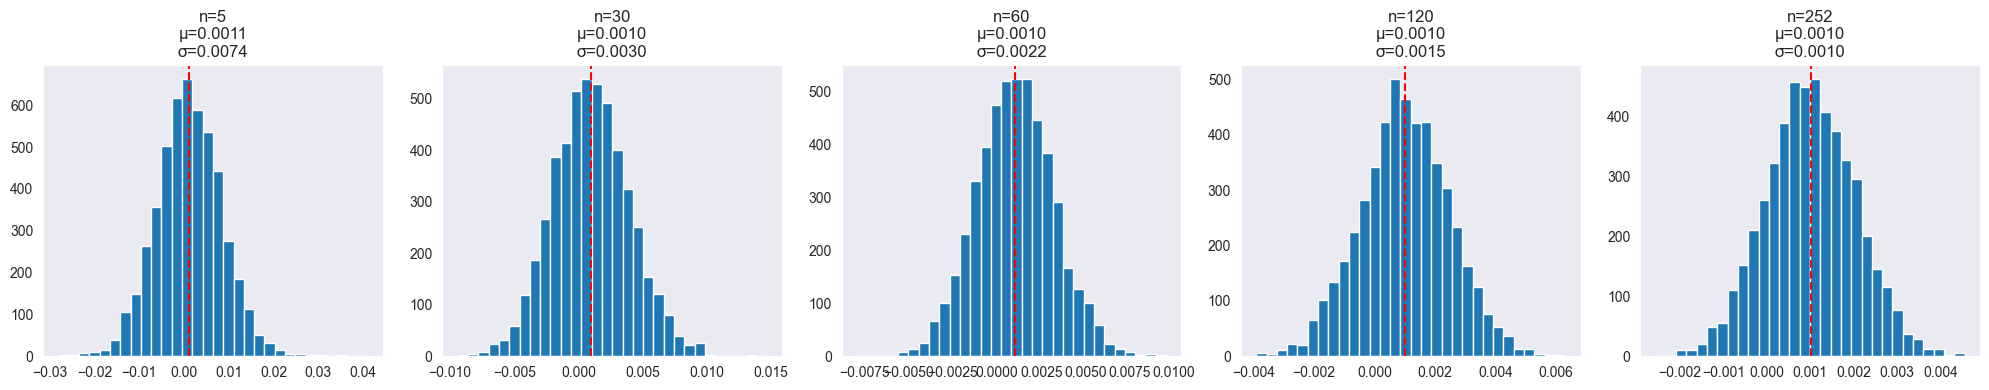

In [138]:
fig, ax = plt.subplots(1, 5, figsize=(20,4))

for i, n in enumerate(muestras):
    
    datos = resultados_mc[n]
    
    ax[i].hist(datos, bins=30)
    ax[i].axvline(datos.mean(), color="red", linestyle="--")
    
    ax[i].set_title(
        f"n={n}\nμ={datos.mean():.4f}\nσ={datos.std():.4f}"
    )

plt.tight_layout()
plt.show()

# Teorema del Límite Central
A medida que aumenta el tamaño de la muestra, la distribución del retorno promedio se vuelve más concentrada alrededor de la media y presenta una menor dispersión. Esto se observa en el gráfico, donde la desviación estándar disminuye desde 0,0074 para n=5 hasta 0,0010 para n=252.
Además, las distribuciones adquieren una forma cada vez más simétrica y estable. Esto coincide con el Teorema del Límite Central, que indica que al aumentar el tamaño de la muestra, la distribución de las medias tiende a aproximarse a una distribución normal.
Esto es importante porque permite obtener estimaciones más precisas y confiables del retorno esperado cuando se trabaja con una mayor cantidad de datos.

# 📈 4.2 Propiedades de los Estimadores

Se sabe 
 
$$
E\left(\sum_{i=1}^{n}X_i\right)=n\mu
$$

Para cada estimador:

$$
E(\hat{\mu}_1)=E\left(\frac{1}{n-1}\sum_{i=1}^{n}X_i\right)
=\frac{n}{n-1}\mu
$$

Por lo tanto,

$$
b(\hat{\mu}_1)=E(\hat{\mu}_1)-\mu
=\frac{\mu}{n-1}
$$

por lo que es un estimador sesgado.

Para el segundo estimador:

$$
E(\hat{\mu}_2)=E\left(\frac{1}{n}\sum_{i=1}^{n}X_i\right)
=\mu
$$

y su sesgo es:

$$
b(\hat{\mu}_2)=0
$$

Por lo tanto, $\hat{\mu}_2$ es insesgado.

Finalmente,

$$
E(\hat{\mu}_3)=E\left(\frac{1}{n+1}\sum_{i=1}^{n}X_i\right)
=\frac{n}{n+1}\mu
$$

y su sesgo es:

$$
b(\hat{\mu}_3)=
-\frac{\mu}{n+1}
$$

por lo que también es sesgado.

En conclusión, el único estimador insesgado es:

$$
\hat{\mu}_2=\frac{1}{n}\sum_{i=1}^{n}X_i
$$

In [139]:
# Retornos de AMZN
amzn = retornos_simples["AMZN"].dropna()

mu_real = amzn.mean()

n = 30
n_sim = 10000

mu1 = []
mu2 = []
mu3 = []

for _ in range(n_sim):

    muestra = np.random.choice(amzn, size=n, replace=True)

    mu1.append(np.sum(muestra)/(n-1))
    mu2.append(np.sum(muestra)/n)
    mu3.append(np.sum(muestra)/(n+1))

print("Media poblacional:", mu_real)
print("E(mu1):", np.mean(mu1))
print("E(mu2):", np.mean(mu2))
print("E(mu3):", np.mean(mu3))

Media poblacional: 0.000574810315570597
E(mu1): 0.0005897681196082665
E(mu2): 0.000570109182287991
E(mu3): 0.0005517185635045074


In [140]:
tamanos = [10, 30, 100, 500]
n_sim = 10000

ecm_resultados = []

for n in tamanos:
    mu1 = []
    mu2 = []
    mu3 = []
    
    for _ in range(n_sim):
        muestra = np.random.choice(amzn, size=n, replace=True)
        
        est1 = np.sum(muestra) / (n - 1)
        est2 = np.sum(muestra) / n
        est3 = np.sum(muestra) / (n + 1)
        
        mu1.append(est1)
        mu2.append(est2)
        mu3.append(est3)
    
    ecm_resultados.append({
        "n": n,
        "ECM_mu1": np.mean((np.array(mu1) - mu_real) ** 2),
        "ECM_mu2": np.mean((np.array(mu2) - mu_real) ** 2),
        "ECM_mu3": np.mean((np.array(mu3) - mu_real) ** 2)
    })

ecm_df = pd.DataFrame(ecm_resultados)
ecm_df

,n,ECM_mu1,ECM_mu2,ECM_mu3
0,10,6.135583e-05,4.968379e-05,4.105453e-05
1,30,1.779893e-05,1.662942e-05,1.557202e-05
2,100,5.019619e-06,4.919811e-06,4.823017e-06
3,500,9.851518e-07,9.811831e-07,9.772408e-07


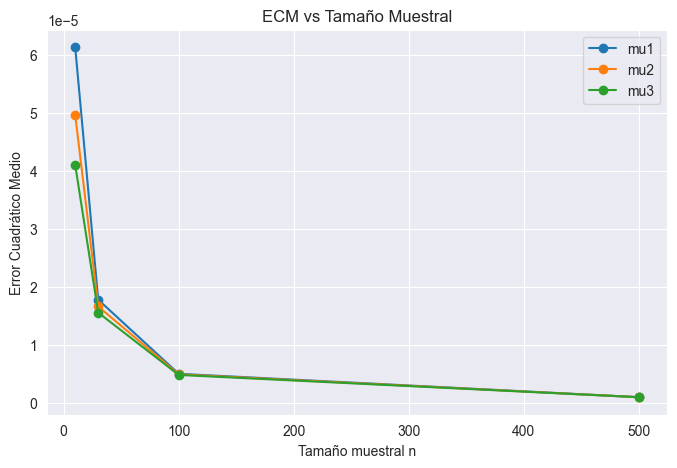

In [141]:
plt.figure(figsize=(8,5))

plt.plot(ecm_df["n"], ecm_df["ECM_mu1"], marker="o", label="mu1")
plt.plot(ecm_df["n"], ecm_df["ECM_mu2"], marker="o", label="mu2")
plt.plot(ecm_df["n"], ecm_df["ECM_mu3"], marker="o", label="mu3")

plt.title("ECM vs Tamaño Muestral")
plt.xlabel("Tamaño muestral n")
plt.ylabel("Error Cuadrático Medio")
plt.legend()
plt.grid(True)

plt.show()

# Propiedad asintótica
En el gráfico se observa que el ECM disminuye a medida que aumenta el tamaño muestral n. Esto significa que, mientras más datos se utilizan, los estimadores se vuelven más precisos y se acercan más a la media real.
Este comportamiento refleja la propiedad de consistencia, ya que el error de estimación tiende a reducirse cuando aumenta la muestra.
Para tamaños muestrales pequeños,  
μ3​	presenta el menor ECM en la simulación, por lo que sería el más conveniente si se busca minimizar el error. Sin embargo,μ2 es el único estimador insesgado, por lo que también es una opción adecuada desde el punto de vista teórico.